<div style="font-size: 60px; font-weight: bold" align="center">
🐔 La poule qui chante 🍗
</div>
<div style="font-size: 48px;" align="center">
Étude de marché &ndash; Export à l'international
</div>

<div style="font-size: 42px;">
📓 Préparation des données
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

In [2]:
data_path = "../data/"

# Fichiers fournis

## Disponibilité alimentaire (2017)

In [3]:
df_dispo_alim_ = pd.read_csv(data_path + "DisponibiliteAlimentaire_2017.csv")
df_dispo_alim_

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.00,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.00,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176595,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,5142,Nourriture,2899,Miscellanees,2017,2017,Milliers de tonnes,19.00,S,Données standardisées
176596,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,645,Disponibilité alimentaire en quantité (kg/pers...,2899,Miscellanees,2017,2017,kg,1.33,Fc,Donnée calculée
176597,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2899,Miscellanees,2017,2017,Kcal/personne/jour,1.00,Fc,Donnée calculée
176598,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2899,Miscellanees,2017,2017,g/personne/jour,0.04,Fc,Donnée calculée


In [4]:
df_dispo_alim_.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  str    
 1   Domaine                 176600 non-null  str    
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  str    
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  str    
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  str    
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  str    
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  str    
 13  Description du Symbole  176600 non-null  str    
dtypes: float64(1), int64(5), str(8)

In [5]:
df_dispo_alim_.nunique()

Code Domaine                 1
Domaine                      1
Code zone                  174
Zone                       174
Code Élément                17
Élément                     17
Code Produit                98
Produit                     98
Code année                   1
Année                        1
Unité                        4
Valeur                    7250
Symbole                      2
Description du Symbole       2
dtype: int64

In [6]:
df_dispo_alim_.groupby(["Élément","Unité"]).size()

Élément                                                        Unité             
Alimentation pour touristes                                    Milliers de tonnes     5560
Aliments pour animaux                                          Milliers de tonnes     4188
Autres utilisations (non alimentaire)                          Milliers de tonnes     5292
Disponibilité alimentaire (Kcal/personne/jour)                 Kcal/personne/jour    14476
Disponibilité alimentaire en quantité (kg/personne/an)         kg                    14618
Disponibilité de matière grasse en quantité (g/personne/jour)  g/personne/jour       14512
Disponibilité de protéines en quantité (g/personne/jour)       g/personne/jour       14507
Disponibilité intérieure                                       Milliers de tonnes    15905
Exportations - Quantité                                        Milliers de tonnes    12113
Importations - Quantité                                        Milliers de tonnes    15260
Nourritu

In [7]:
df_dispo_alim_.groupby(["Symbole","Description du Symbole"]).size()

Symbole  Description du Symbole
Fc       Donnée calculée            58113
S        Données standardisées     118487
dtype: int64

In [8]:
np.sort(df_dispo_alim_["Produit"].unique())

array(['Abats Comestible', 'Agrumes, Autres', 'Alcool, non Comestible',
       'Aliments pour enfants', 'Ananas et produits',
       'Animaux Aquatiques Autre', 'Arachides Decortiquees', 'Avoine',
       'Bananes', 'Bananes plantains', 'Beurre, Ghee', 'Bière',
       'Blé et produits', 'Boissons Alcooliques', 'Boissons Fermentés',
       'Café et produits', 'Cephalopodes', 'Citrons & Limes et produits',
       'Coco (Incl Coprah)', 'Crustacés', 'Crème', 'Céréales, Autres',
       'Dattes', 'Edulcorants Autres', 'Feve de Cacao et produits',
       'Fruits, Autres', 'Girofles', 'Graines Colza/Moutarde',
       'Graines de coton', 'Graines de tournesol',
       'Graisses Animales Crue', 'Haricots', 'Huil Plantes Oleif Autr',
       'Huile Graines de Coton', "Huile d'Arachide", "Huile d'Olive",
       'Huile de Coco', 'Huile de Colza&Moutarde',
       'Huile de Germe de Maïs', 'Huile de Palme', 'Huile de Palmistes',
       'Huile de Soja', 'Huile de Son de Riz', 'Huile de Sésame',
       '

In [9]:
df_dispo_alim_ = df_dispo_alim_[ (df_dispo_alim_["Produit"] == "Viande de Volailles") ]
df_dispo_alim_ = df_dispo_alim_[["Code zone","Zone","Élément","Valeur"]]
df_dispo_alim_.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 2061 entries, 651 to 176400
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code zone  2061 non-null   int64  
 1   Zone       2061 non-null   str    
 2   Élément    2061 non-null   str    
 3   Valeur     2061 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 163.5 KB


In [10]:
df_dispo_alim_ = df_dispo_alim_.pivot(index=["Code zone","Zone"], columns="Élément", values="Valeur").reset_index()
df_dispo_alim_.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 19 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Code zone                                                      172 non-null    int64  
 1   Zone                                                           172 non-null    str    
 2   Alimentation pour touristes                                    78 non-null     float64
 3   Aliments pour animaux                                          1 non-null      float64
 4   Autres utilisations (non alimentaire)                          34 non-null     float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 172 non-null    float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         172 non-null    float64
 7   Disponibilité de matière grasse en quantité (g/personne/jour)  172 non-nu

In [11]:
df_dispo_alim_ = df_dispo_alim_[[
    "Code zone", "Zone", "Production", "Importations - Quantité", "Exportations - Quantité"
]]
df_dispo_alim_.rename(
    columns={"Importations - Quantité":"Importation","Exportations - Quantité":"Exportation"},
    inplace=True,
)
df_dispo_alim_.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Code zone    172 non-null    int64  
 1   Zone         172 non-null    str    
 2   Production   168 non-null    float64
 3   Importation  170 non-null    float64
 4   Exportation  135 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 8.7 KB


In [12]:
df_dispo_alim_.dropna(inplace=True)
df_dispo_alim_.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 135 entries, 0 to 170
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Code zone    135 non-null    int64  
 1   Zone         135 non-null    str    
 2   Production   135 non-null    float64
 3   Importation  135 non-null    float64
 4   Exportation  135 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 7.7 KB


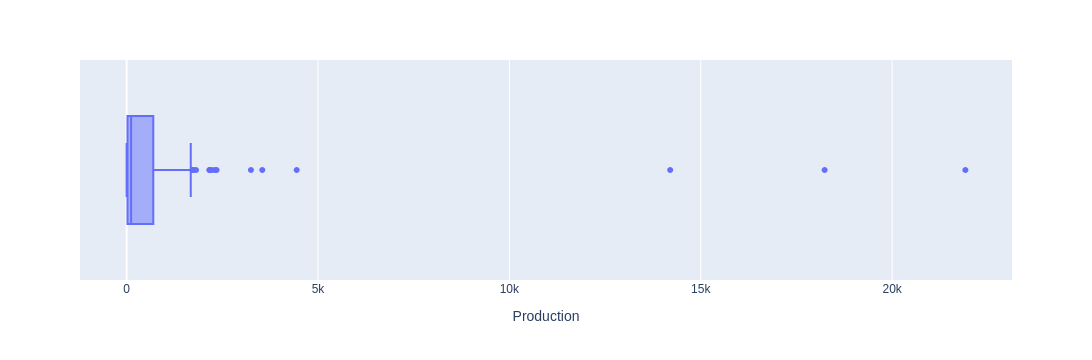

In [13]:
px.box(df_dispo_alim_, x="Production", hover_name="Zone")

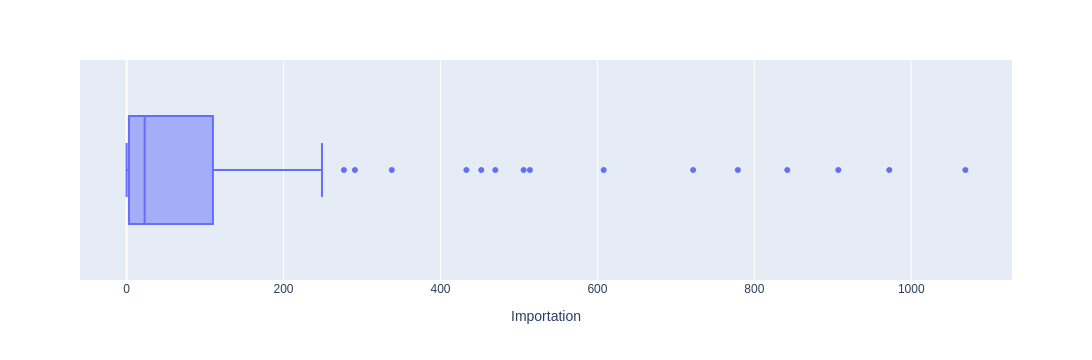

In [14]:
px.box(df_dispo_alim_, x="Importation", hover_name="Zone")

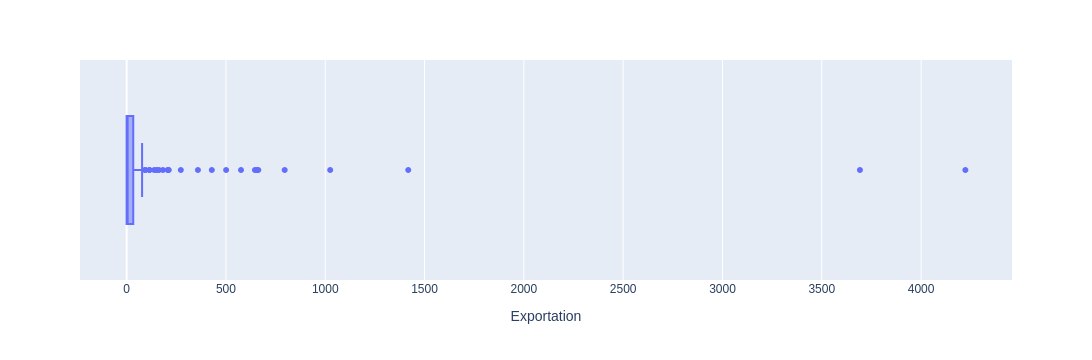

In [15]:
px.box(df_dispo_alim_, x="Exportation", hover_name="Zone")

## Population (2000-2018)

In [16]:
df_population_ = pd.read_csv(data_path + "Population_2000_2018.csv")
df_population_

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2014,2014,1000 personnes,13586.707,X,Sources internationales sûres,NaN
4407,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2015,2015,1000 personnes,13814.629,X,Sources internationales sûres,NaN
4408,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2016,2016,1000 personnes,14030.331,X,Sources internationales sûres,NaN
4409,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,14236.595,X,Sources internationales sûres,NaN


In [17]:
df_population_.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   str    
 1   Domaine                 4411 non-null   str    
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   str    
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   str    
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   str    
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   str    
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   str    
 13  Description du Symbole  4411 non-null   str    
 14  Note                    258 non-null    str    
dty

In [18]:
df_population_.nunique()

Code Domaine                 1
Domaine                      1
Code zone                  238
Zone                       238
Code Élément                 1
Élément                      1
Code Produit                 1
Produit                      1
Code année                  19
Année                       19
Unité                        1
Valeur                    4398
Symbole                      2
Description du Symbole       2
Note                         1
dtype: int64

In [19]:
df_population_.groupby(["Élément","Unité"]).size()

Élément            Unité         
Population totale  1000 personnes    4411
dtype: int64

In [20]:
df_population_.groupby(["Symbole","Description du Symbole"]).size()

Symbole  Description du Symbole                                                                
A        Agrégat, peut inclure des données officielles, semi-officielles, estimées ou calculées      37
X        Sources internationales sûres                                                             4374
dtype: int64

In [21]:
np.sort(df_population_["Année"].unique())

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [22]:
df_population_ = df_population_[ (df_population_["Symbole"] == "X") ]
df_population_ = df_population_[["Code zone","Zone","Année","Valeur"]]
df_population_["Valeur"] *= 1000
df_population_ = df_population_.pivot(index=["Code zone","Zone"], columns="Année", values="Valeur").reset_index()
df_population_.columns = list(map(str, df_population_.columns))
df_population_

,Code zone,Zone,2000,2001,2002,2003,2004,2005,2006,2007,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,1,Arménie,3069591.0,3050687.0,3033978.0,3017932.0,3000720.0,2981269.0,2958307.0,2932618.0,...,2888092.0,2877319.0,2876538.0,2884234.0,2897588.0,2912409.0,2925553.0,2936143.0,2944791.0,2951745.0
1,2,Afghanistan,20779953.0,21606988.0,22600770.0,23680871.0,24726684.0,25654277.0,26433049.0,27100536.0,...,28394813.0,29185507.0,30117413.0,31161376.0,32269589.0,33370794.0,34413603.0,35383032.0,36296113.0,37171921.0
2,3,Albanie,3129243.0,3129704.0,3126187.0,3118023.0,3104892.0,3086810.0,3063021.0,3033998.0,...,2973048.0,2948023.0,2928592.0,2914096.0,2903790.0,2896305.0,2890513.0,2886438.0,2884169.0,2882740.0
3,4,Algérie,31042235.0,31451514.0,31855109.0,32264157.0,32692163.0,33149724.0,33641002.0,34166972.0,...,35333881.0,35977455.0,36661445.0,37383895.0,38140133.0,38923692.0,39728025.0,40551392.0,41389189.0,42228408.0
4,5,Samoa américaines,57821.0,58494.0,59080.0,59504.0,59681.0,59562.0,59107.0,58365.0,...,56683.0,56079.0,55759.0,55667.0,55713.0,55791.0,55812.0,55741.0,55620.0,55465.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,279,Curaçao,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,152315.0,154817.0,156794.0,158422.0,159847.0,161052.0,161997.0,162752.0
231,280,Sint Maarten (partie néerlandaise),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,35058.0,36241.0,37583.0,38876.0,39968.0,40808.0,41444.0,41940.0
232,281,Saint-Martin (partie française),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,37446.0,37009.0,36453.0,36015.0,35858.0,36065.0,36560.0,37264.0
233,282,Saint-Barthélemy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,9343.0,9439.0,9537.0,9623.0,9693.0,9748.0,9784.0,9816.0


In [23]:
df_population_.nunique()

Code zone    235
Zone         235
2000         226
2001         226
2002         226
2003         226
2004         226
2005         226
2006         228
2007         228
2008         228
2009         228
2010         228
2011         233
2012         235
2013         235
2014         235
2015         235
2016         235
2017         235
2018         235
dtype: int64

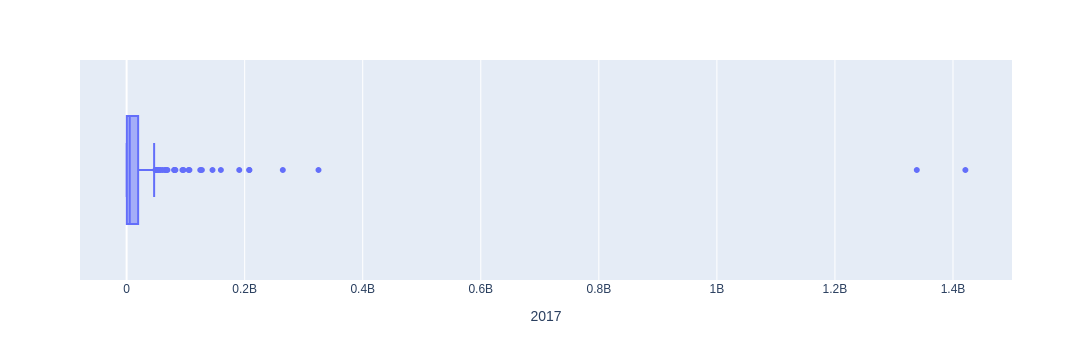

In [24]:
px.box(df_population_, x="2017", hover_name="Zone")

# Fichiers actualisés avec codes pays au format ISO3

## Disponibilité alimentaire (2018)

Source : https://www.fao.org/faostat/fr/#data/FBS

Seules les données pour le produit "Viande de Volailles" ont été téléchargées.

In [25]:
df_dispo_alim = pd.read_csv(data_path + "fao-fbs-2018.csv")
df_dispo_alim

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit (FBS),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5511,Production,S2734,Viande de Volailles,2018,2018,1000 t,29.00,I,Valeur imputée par une agence réceptrice,NaN
1,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5611,Importations - quantité,S2734,Viande de Volailles,2018,2018,1000 t,25.00,I,Valeur imputée par une agence réceptrice,NaN
2,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5072,Variation de stock,S2734,Viande de Volailles,2018,2018,1000 t,0.00,I,Valeur imputée par une agence réceptrice,NaN
3,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5911,Exportations - quantité,S2734,Viande de Volailles,2018,2018,1000 t,0.00,I,Valeur imputée par une agence réceptrice,NaN
4,FBS,Bilans Alimentaires (2010-),AFG,Afghanistan,5301,Disponibilité intérieure,S2734,Viande de Volailles,2018,2018,1000 t,53.00,I,Valeur imputée par une agence réceptrice,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2541,FBS,Bilans Alimentaires (2010-),ZWE,Zimbabwe,661,Disponibilité alimentaire (Kcal),S2734,Viande de Volailles,2018,2018,millions de kcal,90912.15,I,Valeur imputée par une agence réceptrice,NaN
2542,FBS,Bilans Alimentaires (2010-),ZWE,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,S2734,Viande de Volailles,2018,2018,g/personne/jour,1.98,E,Valeur estimée,NaN
2543,FBS,Bilans Alimentaires (2010-),ZWE,Zimbabwe,671,Disponibilité de protéines en quantité (t),S2734,Viande de Volailles,2018,2018,tonnes,10867.47,I,Valeur imputée par une agence réceptrice,NaN
2544,FBS,Bilans Alimentaires (2010-),ZWE,Zimbabwe,684,Disponibilité de matière grasse en quantité (g...,S2734,Viande de Volailles,2018,2018,g/personne/jour,0.96,E,Valeur estimée,NaN


In [26]:
df_dispo_alim.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 2546 entries, 0 to 2545
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            2546 non-null   str    
 1   Domaine                 2546 non-null   str    
 2   Code zone (ISO3)        2546 non-null   str    
 3   Zone                    2546 non-null   str    
 4   Code Élément            2546 non-null   int64  
 5   Élément                 2546 non-null   str    
 6   Code Produit (FBS)      2546 non-null   str    
 7   Produit                 2546 non-null   str    
 8   Code année              2546 non-null   int64  
 9   Année                   2546 non-null   int64  
 10  Unité                   2546 non-null   str    
 11  Valeur                  2546 non-null   float64
 12  Symbole                 2546 non-null   str    
 13  Description du Symbole  2546 non-null   str    
 14  Note                    0 non-null      float64
dty

In [27]:
df_dispo_alim.nunique()

Code Domaine                 1
Domaine                      1
Code zone (ISO3)           171
Zone                       171
Code Élément                18
Élément                     18
Code Produit (FBS)           1
Produit                      1
Code année                   1
Année                        1
Unité                        6
Valeur                    1468
Symbole                      2
Description du Symbole       2
Note                         0
dtype: int64

In [28]:
df_dispo_alim.groupby(["Élément","Unité"]).size()

Élément                                                        Unité             
Alimentation pour touristes                                    1000 t                 40
Autres utilisations (non alimentaire)                          1000 t                 31
Disponibilité alimentaire (Kcal)                               millions de kcal      171
Disponibilité alimentaire (Kcal/personne/jour)                 kcal/personne/jour    171
Disponibilité alimentaire en quantité (kg/personne/an)         kg/personne           171
Disponibilité de matière grasse en quantité (g/personne/jour)  g/personne/jour       171
Disponibilité de matière grasse en quantité (t)                tonnes                171
Disponibilité de protéines en quantité (g/personne/jour)       g/personne/jour       171
Disponibilité de protéines en quantité (t)                     tonnes                171
Disponibilité intérieure                                       1000 t                171
Exportations - quantité     

In [29]:
df_dispo_alim.groupby(["Symbole","Description du Symbole"]).size()

Symbole  Description du Symbole                  
E        Valeur estimée                               697
I        Valeur imputée par une agence réceptrice    1849
dtype: int64

In [30]:
np.sort(df_dispo_alim["Produit"].unique())

array(['Viande de Volailles'], dtype=object)

In [31]:
df_dispo_alim = df_dispo_alim[["Code zone (ISO3)","Zone","Élément","Valeur"]]
df_dispo_alim.rename(columns={"Code zone (ISO3)":"ISO3"}, inplace=True)
df_dispo_alim.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 2546 entries, 0 to 2545
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ISO3     2546 non-null   str    
 1   Zone     2546 non-null   str    
 2   Élément  2546 non-null   str    
 3   Valeur   2546 non-null   float64
dtypes: float64(1), str(3)
memory usage: 196.2 KB


In [32]:
df_dispo_alim = df_dispo_alim.pivot(index=["ISO3","Zone"], columns="Élément", values="Valeur")
df_dispo_alim.info(verbose=True)

<class 'pandas.DataFrame'>
MultiIndex: 171 entries, ('AFG', 'Afghanistan') to ('ZWE', 'Zimbabwe')
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Alimentation pour touristes                                    40 non-null     float64
 1   Autres utilisations (non alimentaire)                          31 non-null     float64
 2   Disponibilité alimentaire (Kcal)                               171 non-null    float64
 3   Disponibilité alimentaire (Kcal/personne/jour)                 171 non-null    float64
 4   Disponibilité alimentaire en quantité (kg/personne/an)         171 non-null    float64
 5   Disponibilité de matière grasse en quantité (g/personne/jour)  171 non-null    float64
 6   Disponibilité de matière grasse en quantité (t)                171 non-null    float64
 7   Disponibilité de protéines en quanti

In [33]:
df_dispo_alim = df_dispo_alim[[
    "Production", "Importations - quantité", "Exportations - quantité",
]]
df_dispo_alim.rename(
    columns={"Importations - quantité":"Importation","Exportations - quantité":"Exportation"},
    inplace=True,
)
df_dispo_alim.reset_index(level="Zone", inplace=True)
df_dispo_alim.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 171 entries, AFG to ZWE
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Zone         171 non-null    str    
 1   Production   169 non-null    float64
 2   Importation  171 non-null    float64
 3   Exportation  135 non-null    float64
dtypes: float64(3), str(1)
memory usage: 9.1 KB


In [34]:
df_dispo_alim.dropna(inplace=True)
df_dispo_alim.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 135 entries, AFG to ZMB
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Zone         135 non-null    str    
 1   Production   135 non-null    float64
 2   Importation  135 non-null    float64
 3   Exportation  135 non-null    float64
dtypes: float64(3), str(1)
memory usage: 7.2 KB


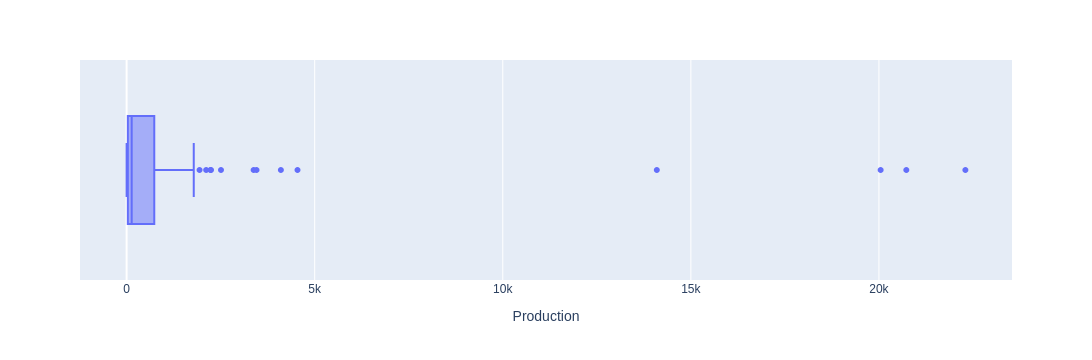

In [35]:
px.box(df_dispo_alim, x="Production", hover_name="Zone")

In [36]:
df_dispo_alim[ df_dispo_alim["Zone"].str.contains("Chine") ]

Élément,Zone,Production,Importation,Exportation
ISO3,,,,
CHN,"Chine, continentale",20045.0,504.0,594.0
F351,Chine,20728.0,1575.0,1210.0
HKG,Chine - RAS de Hong-Kong,25.0,829.0,608.0
MAC,Chine - RAS de Macao,4.0,26.0,0.0
TWN,"Chine, Taiwan Province de",654.0,217.0,8.0


In [37]:
df_dispo_alim[ ~df_dispo_alim.index.str.fullmatch("[A-Z]{3}") ]

Élément,Zone,Production,Importation,Exportation
ISO3,,,,
F351,Chine,20728.0,1575.0,1210.0


In [38]:
df_dispo_alim.drop(index="F351", inplace=True)
df_dispo_alim.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 134 entries, AFG to ZMB
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Zone         134 non-null    str    
 1   Production   134 non-null    float64
 2   Importation  134 non-null    float64
 3   Exportation  134 non-null    float64
dtypes: float64(3), str(1)
memory usage: 7.1 KB


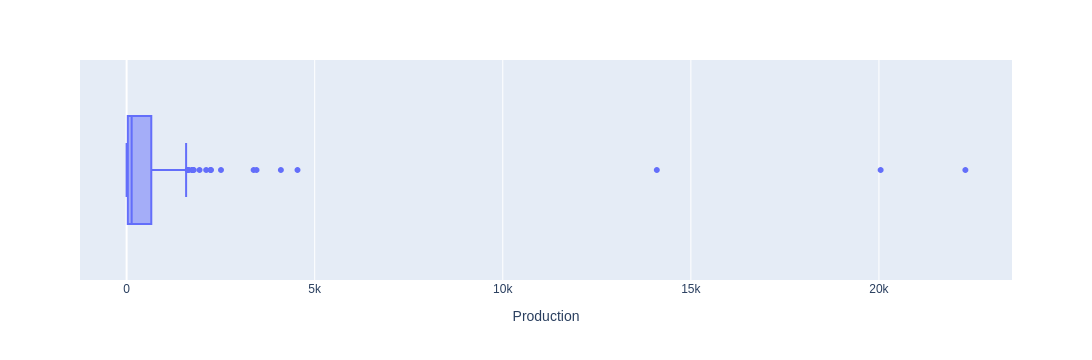

In [39]:
px.box(df_dispo_alim, x="Production", hover_name="Zone")

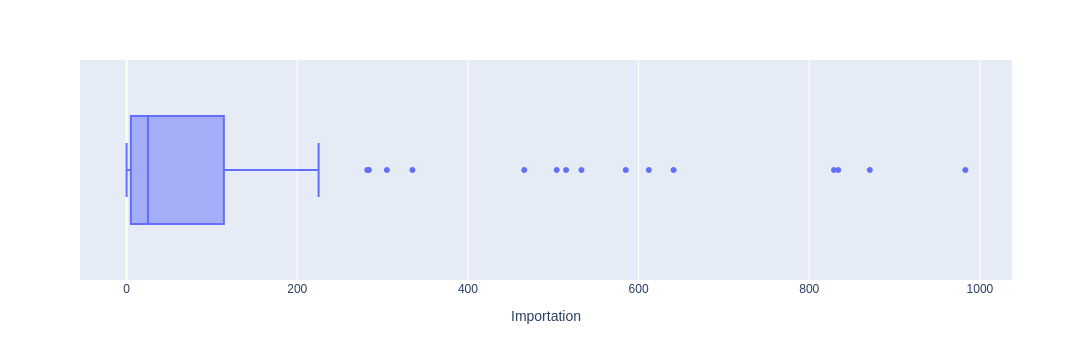

In [40]:
px.box(df_dispo_alim, x="Importation", hover_name="Zone")

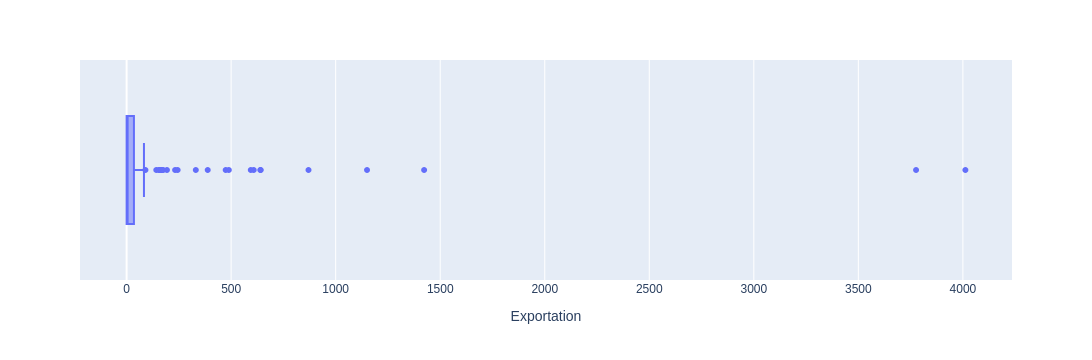

In [41]:
px.box(df_dispo_alim, x="Exportation", hover_name="Zone")

### Feature engineering : taux de dépendance des importations

TDI = Taux de dépendance des importations

Définition : https://www.fao.org/4/X9892F/x9892f09.htm

In [42]:
df_dispo_alim["TDI"] = df_dispo_alim["Importation"] / (df_dispo_alim["Production"] + df_dispo_alim["Importation"] - df_dispo_alim["Exportation"])
df_dispo_alim["TDI"].describe()

count    134.000000
mean       0.380610
std        0.494137
min        0.000000
25%        0.042520
50%        0.201180
75%        0.674716
max        3.369919
Name: TDI, dtype: float64

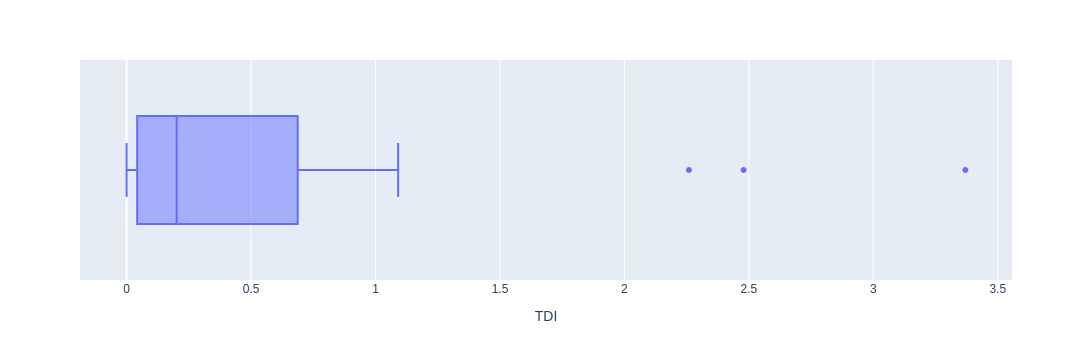

In [43]:
px.box(df_dispo_alim, x="TDI", hover_name="Zone")

### Feature engineering : taux d'auto-suffisance

TAS = Taux d'auto-suffisance

Définition : https://www.fao.org/4/x9892f/x9892f0a.htm

In [44]:
df_dispo_alim["TAS"] = df_dispo_alim["Production"] / (df_dispo_alim["Production"] + df_dispo_alim["Importation"] - df_dispo_alim["Exportation"])
df_dispo_alim["TAS"].describe()

count    134.000000
mean       0.816233
std        0.550104
min        0.000000
25%        0.585038
50%        0.888889
75%        0.999858
max        4.550847
Name: TAS, dtype: float64

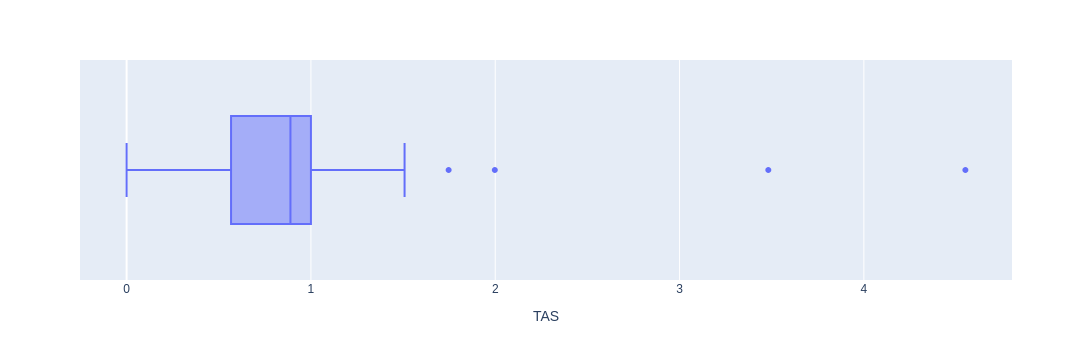

In [45]:
px.box(df_dispo_alim, x="TAS", hover_name="Zone")

## Population (2000-2023)

Source : https://www.fao.org/faostat/fr/#data/OA

In [46]:
df_population = pd.read_csv(data_path + "fao-oa-2000-2023.csv")
df_population

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 No,20130.327,X,Chiffre de source externe,NaN
1,OA,Séries temporelles annuelles,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 No,20284.307,X,Chiffre de source externe,NaN
2,OA,Séries temporelles annuelles,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 No,21378.117,X,Chiffre de source externe,NaN
3,OA,Séries temporelles annuelles,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 No,22733.049,X,Chiffre de source externe,NaN
4,OA,Séries temporelles annuelles,AFG,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 No,23560.654,X,Chiffre de source externe,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5549,OA,Séries temporelles annuelles,ZWE,Zimbabwe,511,Population totale,3010,Population-Estimations,2019,2019,1000 No,15271.368,X,Chiffre de source externe,NaN
5550,OA,Séries temporelles annuelles,ZWE,Zimbabwe,511,Population totale,3010,Population-Estimations,2020,2020,1000 No,15526.888,X,Chiffre de source externe,NaN
5551,OA,Séries temporelles annuelles,ZWE,Zimbabwe,511,Population totale,3010,Population-Estimations,2021,2021,1000 No,15797.210,X,Chiffre de source externe,NaN
5552,OA,Séries temporelles annuelles,ZWE,Zimbabwe,511,Population totale,3010,Population-Estimations,2022,2022,1000 No,16069.056,X,Chiffre de source externe,NaN


In [47]:
df_population.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 5554 entries, 0 to 5553
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            5554 non-null   str    
 1   Domaine                 5554 non-null   str    
 2   Code zone (ISO3)        5554 non-null   str    
 3   Zone                    5554 non-null   str    
 4   Code Élément            5554 non-null   int64  
 5   Élément                 5554 non-null   str    
 6   Code Produit            5554 non-null   int64  
 7   Produit                 5554 non-null   str    
 8   Code année              5554 non-null   int64  
 9   Année                   5554 non-null   int64  
 10  Unité                   5554 non-null   str    
 11  Valeur                  5554 non-null   float64
 12  Symbole                 5554 non-null   str    
 13  Description du Symbole  5554 non-null   str    
 14  Note                    0 non-null      float64
dty

In [48]:
df_population.nunique()

Code Domaine                 1
Domaine                      1
Code zone (ISO3)           237
Zone                       237
Code Élément                 1
Élément                      1
Code Produit                 1
Produit                      1
Code année                  24
Année                       24
Unité                        1
Valeur                    5547
Symbole                      2
Description du Symbole       2
Note                         0
dtype: int64

In [49]:
df_population.groupby(["Élément","Unité"]).size()

Élément            Unité  
Population totale  1000 No    5554
dtype: int64

In [50]:
df_population.groupby(["Symbole","Description du Symbole"]).size()

Symbole  Description du Symbole   
E        Valeur estimée                 29
X        Chiffre de source externe    5525
dtype: int64

In [51]:
np.sort(df_population["Année"].unique())

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

In [52]:
df_population = df_population[ (df_population["Symbole"] == "X") ]
df_population = df_population[["Code zone (ISO3)","Zone","Année","Valeur"]]
df_population.rename(columns={"Code zone (ISO3)":"ISO3"}, inplace=True)
df_population["Valeur"] *= 1000
df_population = df_population.pivot(index=["ISO3","Zone"], columns="Année", values="Valeur")
df_population.columns = list(map(str, df_population.columns))
df_population.reset_index(level="Zone", inplace=True)
df_population

,Zone,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
ISO3,,,,,,,,,,,,,,,,,,,,,
ABW,Aruba,88761.0,90305.0,91379.0,92310.0,93213.0,94230.0,95392.0,96587.0,97805.0,...,103373.0,104184.0,104977.0,105731.0,106432.0,107076.0,107400.0,107558.0,107782.0,107939.0
AFG,Afghanistan,20130327.0,20284307.0,21378117.0,22733049.0,23560654.0,24404567.0,25424094.0,25909852.0,26482622.0,...,32792523.0,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0
AGO,Angola,16194869.0,16747208.0,17327699.0,17943712.0,18600423.0,19291161.0,20015279.0,20778562.0,21578655.0,...,27160769.0,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0
AIA,Anguilla,11177.0,11472.0,11687.0,11874.0,12068.0,12267.0,12470.0,12676.0,12890.0,...,13729.0,14210.0,14320.0,14425.0,14721.0,14823.0,14843.0,14475.0,14180.0,14410.0
ALB,Albanie,3166148.0,3147943.0,3134092.0,3118088.0,3098657.0,3076159.0,3050809.0,3022887.0,2992930.0,...,2903749.0,2898632.0,2897867.0,2898242.0,2894231.0,2885010.0,2871954.0,2849635.0,2827608.0,2811655.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WSM,Samoa,181685.0,183166.0,184471.0,185430.0,186249.0,186978.0,187709.0,188753.0,190107.0,...,200037.0,201782.0,203499.0,205415.0,207582.0,209780.0,211944.0,213779.0,215261.0,216663.0
YEM,Yémen,19624141.0,20226147.0,20835086.0,21456379.0,22095168.0,22790085.0,23543082.0,24318082.0,25111941.0,...,30226309.0,31159379.0,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0
ZAF,Afrique du Sud,47159719.0,47566800.0,48019415.0,48500348.0,48991421.0,49490033.0,49998277.0,50528584.0,51114599.0,...,55594838.0,56723536.0,57259551.0,57635162.0,58613000.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0


In [53]:
df_population.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 234 entries, ABW to ZWE
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    234 non-null    str    
 1   2000    225 non-null    float64
 2   2001    225 non-null    float64
 3   2002    225 non-null    float64
 4   2003    225 non-null    float64
 5   2004    225 non-null    float64
 6   2005    225 non-null    float64
 7   2006    227 non-null    float64
 8   2007    227 non-null    float64
 9   2008    227 non-null    float64
 10  2009    227 non-null    float64
 11  2010    227 non-null    float64
 12  2011    232 non-null    float64
 13  2012    234 non-null    float64
 14  2013    234 non-null    float64
 15  2014    234 non-null    float64
 16  2015    234 non-null    float64
 17  2016    234 non-null    float64
 18  2017    234 non-null    float64
 19  2018    234 non-null    float64
 20  2019    234 non-null    float64
 21  2020    234 non-null    float64
 22  2021    234 non-

In [54]:
df_population.nunique()

Zone    234
2000    225
2001    225
2002    225
2003    225
2004    225
2005    225
2006    227
2007    227
2008    227
2009    227
2010    227
2011    232
2012    234
2013    234
2014    234
2015    234
2016    234
2017    234
2018    234
2019    234
2020    234
2021    234
2022    234
2023    234
dtype: int64

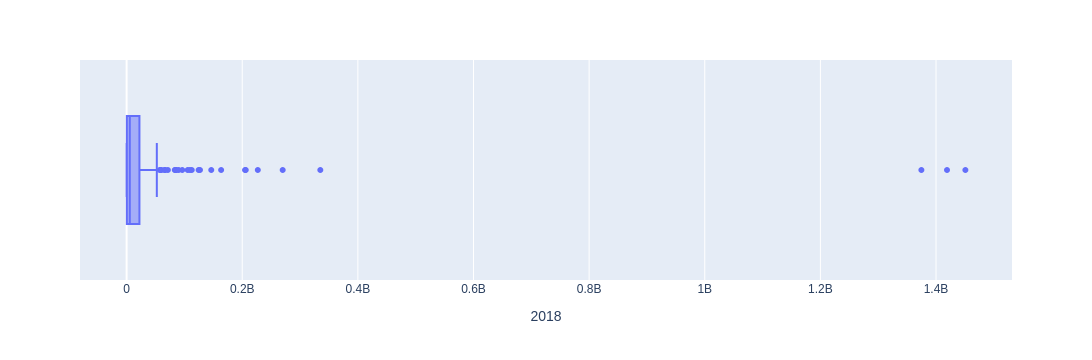

In [55]:
px.box(df_population, x="2018", hover_name="Zone")

In [56]:
df_population[ ~df_population.index.str.fullmatch("[A-Z]{3}") ]

,Zone,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
ISO3,,,,,,,,,,,,,,,,,,,,,
F351,Chine,1.299056e+09,1.308391e+09,1.316711e+09,1.324509e+09,1.332216e+09,1.340256e+09,1.348409e+09,1.356314e+09,1.364464e+09,...,1.419355e+09,1.427652e+09,1.435681e+09,1.444079e+09,1.450798e+09,1.455351e+09,1.457943e+09,1.458175e+09,1.456770e+09,1.454059e+09


In [57]:
df_population.drop(index="F351", inplace=True)
df_population.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 233 entries, ABW to ZWE
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    233 non-null    str    
 1   2000    224 non-null    float64
 2   2001    224 non-null    float64
 3   2002    224 non-null    float64
 4   2003    224 non-null    float64
 5   2004    224 non-null    float64
 6   2005    224 non-null    float64
 7   2006    226 non-null    float64
 8   2007    226 non-null    float64
 9   2008    226 non-null    float64
 10  2009    226 non-null    float64
 11  2010    226 non-null    float64
 12  2011    231 non-null    float64
 13  2012    233 non-null    float64
 14  2013    233 non-null    float64
 15  2014    233 non-null    float64
 16  2015    233 non-null    float64
 17  2016    233 non-null    float64
 18  2017    233 non-null    float64
 19  2018    233 non-null    float64
 20  2019    233 non-null    float64
 21  2020    233 non-null    float64
 22  2021    233 non-

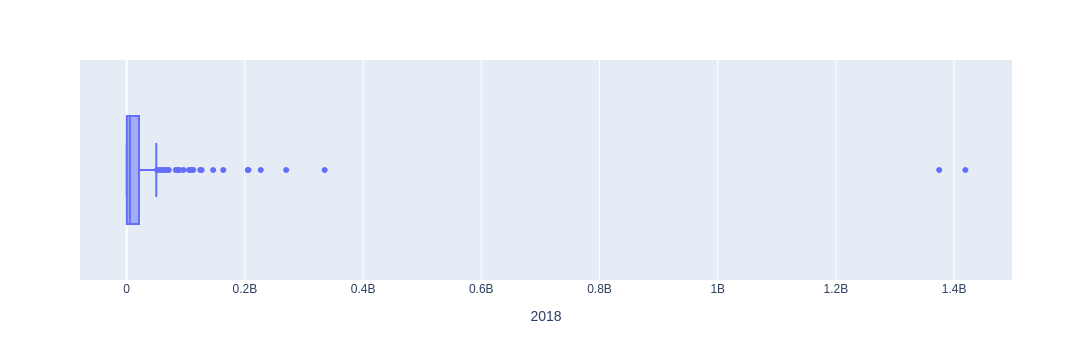

In [58]:
px.box(df_population, x="2018", hover_name="Zone")

### Feature engineering : croissance de la population

Calcul de la croissance de la population sur 10 ans

In [59]:
df_population = df_population[["Zone","2008","2018"]]
df_population["Croissance Population"] = 100. * (df_population["2018"] - df_population["2008"]) / df_population["2008"]
del df_population["2008"]
df_population.rename(columns={"2018":"Population"}, inplace=True)
df_population

,Zone,Population,Croissance Population
ISO3,,,
ABW,Aruba,106432.0,8.820612
AFG,Afghanistan,36743039.0,38.743962
AGO,Angola,31297155.0,45.037561
AIA,Anguilla,14721.0,14.204810
ALB,Albanie,2894231.0,-3.297738
...,...,...,...
WSM,Samoa,207582.0,9.192192
YEM,Yémen,34085182.0,35.732965
ZAF,Afrique du Sud,58613000.0,14.669783


In [60]:
df_population.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 233 entries, ABW to ZWE
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zone                   233 non-null    str    
 1   Population             233 non-null    float64
 2   Croissance Population  226 non-null    float64
dtypes: float64(2), str(1)
memory usage: 10.7 KB


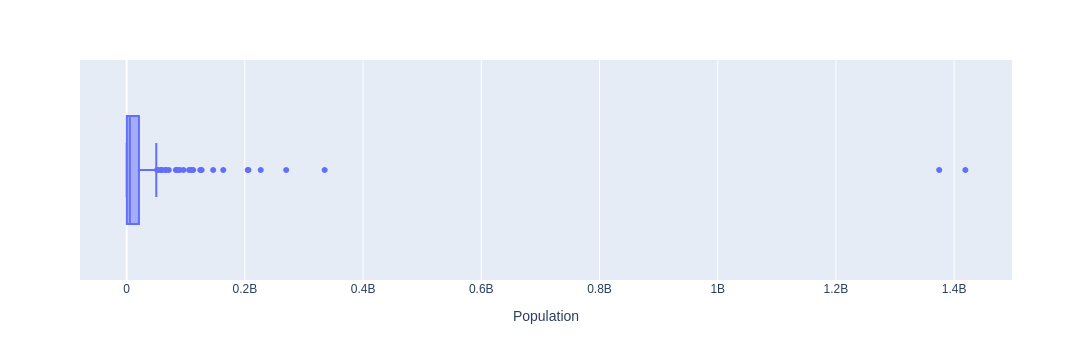

In [61]:
px.box(df_population, x="Population", hover_name="Zone")

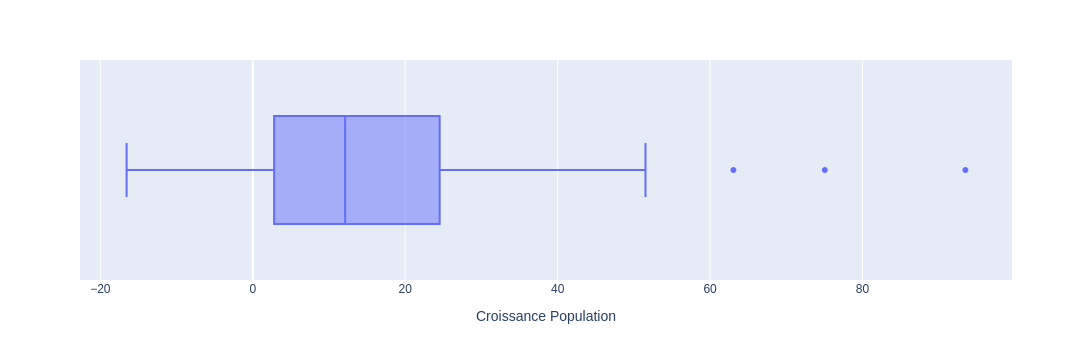

In [62]:
px.box(df_population, x="Croissance Population", hover_name="Zone")

# Autres données de la FAO

## Indicateurs macro économiques (2018)

Source : https://www.fao.org/faostat/fr/#data/MK

In [63]:
df_economy = pd.read_csv(data_path + "fao-mk-2018.csv")
df_economy

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,MK,Indicateurs macro,AFG,Afghanistan,6110,Valeur US$,22008,Produit Intérieur Brut,2018,2018,Millions d’USD,18856.319311,X,Chiffre de source externe,NaN
1,MK,Indicateurs macro,AFG,Afghanistan,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2018,2018,USD,513.194331,X,Chiffre de source externe,NaN
2,MK,Indicateurs macro,AFG,Afghanistan,6129,Croissance annuelle US$,22008,Produit Intérieur Brut,2018,2018,%,-0.935067,X,Chiffre de source externe,NaN
3,MK,Indicateurs macro,AFG,Afghanistan,61290,Croissance annuelle US$ par habitant,22008,Produit Intérieur Brut,2018,2018,%,-3.777096,X,Chiffre de source externe,NaN
4,MK,Indicateurs macro,ZAF,Afrique du Sud,6110,Valeur US$,22008,Produit Intérieur Brut,2018,2018,Millions d’USD,405260.711509,X,Chiffre de source externe,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,MK,Indicateurs macro,ZMB,Zambie,61290,Croissance annuelle US$ par habitant,22008,Produit Intérieur Brut,2018,2018,%,-1.422213,X,Chiffre de source externe,NaN
836,MK,Indicateurs macro,ZWE,Zimbabwe,6110,Valeur US$,22008,Produit Intérieur Brut,2018,2018,Millions d’USD,23645.265549,X,Chiffre de source externe,NaN
837,MK,Indicateurs macro,ZWE,Zimbabwe,6119,Valeur US$ par habitant,22008,Produit Intérieur Brut,2018,2018,USD,1572.738770,X,Chiffre de source externe,NaN
838,MK,Indicateurs macro,ZWE,Zimbabwe,6129,Croissance annuelle US$,22008,Produit Intérieur Brut,2018,2018,%,7.280232,X,Chiffre de source externe,NaN


In [64]:
df_economy[ ~df_economy["Code zone (ISO3)"].str.fullmatch("[A-Z]{3}") ]

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note


In [65]:
df_economy.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            840 non-null    str    
 1   Domaine                 840 non-null    str    
 2   Code zone (ISO3)        840 non-null    str    
 3   Zone                    840 non-null    str    
 4   Code Élément            840 non-null    int64  
 5   Élément                 840 non-null    str    
 6   Code Produit            840 non-null    int64  
 7   Produit                 840 non-null    str    
 8   Code année              840 non-null    int64  
 9   Année                   840 non-null    int64  
 10  Unité                   840 non-null    str    
 11  Valeur                  840 non-null    float64
 12  Symbole                 840 non-null    str    
 13  Description du Symbole  840 non-null    str    
 14  Note                    0 non-null      float64
dtype

In [66]:
df_economy.nunique()

Code Domaine                1
Domaine                     1
Code zone (ISO3)          210
Zone                      210
Code Élément                4
Élément                     4
Code Produit                1
Produit                     1
Code année                  1
Année                       1
Unité                       3
Valeur                    840
Symbole                     1
Description du Symbole      1
Note                        0
dtype: int64

In [67]:
df_economy.groupby(["Élément","Unité"]).size()

Élément                               Unité         
Croissance annuelle US$               %                 210
Croissance annuelle US$ par habitant  %                 210
Valeur US$                            Millions d’USD    210
Valeur US$ par habitant               USD               210
dtype: int64

In [68]:
df_economy = df_economy[["Code zone (ISO3)","Zone","Élément","Valeur"]]
df_economy.rename(columns={"Code zone (ISO3)":"ISO3"}, inplace=True)
df_economy.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ISO3     840 non-null    str    
 1   Zone     840 non-null    str    
 2   Élément  840 non-null    str    
 3   Valeur   840 non-null    float64
dtypes: float64(1), str(3)
memory usage: 56.8 KB


In [69]:
df_economy = df_economy.pivot(index=["ISO3","Zone"], columns="Élément", values="Valeur")
df_economy.reset_index(level="Zone", inplace=True)
df_economy.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 210 entries, ABW to ZWE
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Zone                                  210 non-null    str    
 1   Croissance annuelle US$               210 non-null    float64
 2   Croissance annuelle US$ par habitant  210 non-null    float64
 3   Valeur US$                            210 non-null    float64
 4   Valeur US$ par habitant               210 non-null    float64
dtypes: float64(4), str(1)
memory usage: 12.8 KB


In [70]:
df_economy.rename(columns={
    "Valeur US$":"PIB",
    "Valeur US$ par habitant":"PIB par habitant",
    "Croissance annuelle US$":"Croissance PIB",
    "Croissance annuelle US$ par habitant":"Croissance PIB par habitant",
}, inplace=True)
df_economy.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 210 entries, ABW to ZWE
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Zone                         210 non-null    str    
 1   Croissance PIB               210 non-null    float64
 2   Croissance PIB par habitant  210 non-null    float64
 3   PIB                          210 non-null    float64
 4   PIB par habitant             210 non-null    float64
dtypes: float64(4), str(1)
memory usage: 12.8 KB


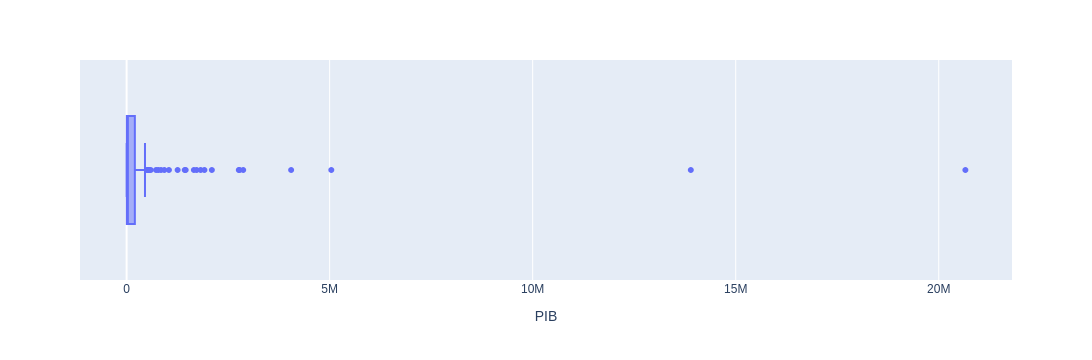

In [71]:
px.box(df_economy, x="PIB", hover_name="Zone")

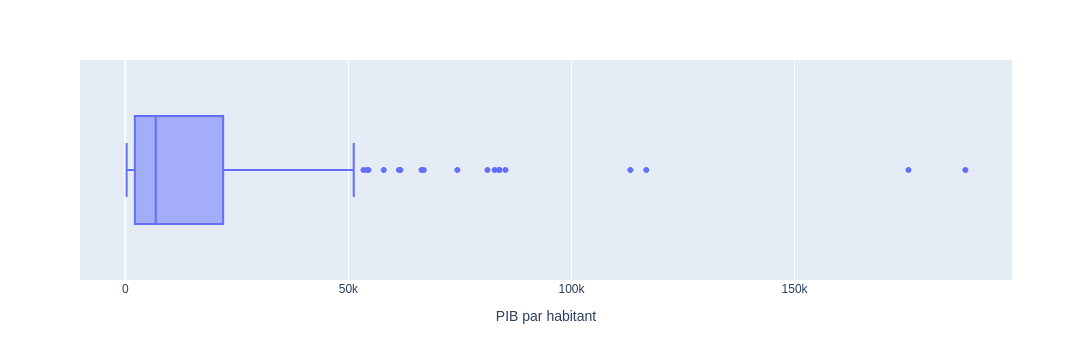

In [72]:
px.box(df_economy, x="PIB par habitant", hover_name="Zone")

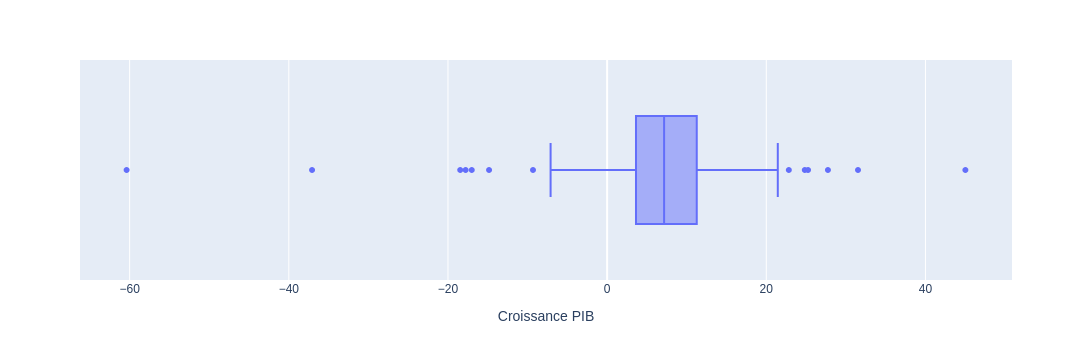

In [73]:
px.box(df_economy, x="Croissance PIB", hover_name="Zone")

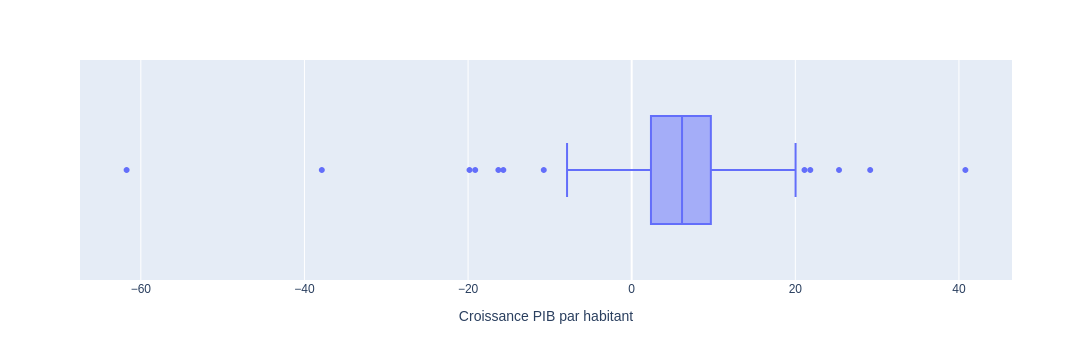

In [74]:
px.box(df_economy, x="Croissance PIB par habitant", hover_name="Zone")

## Coût et abordabilité d’une alimentation saine (2018)

Source : https://www.fao.org/faostat/fr/#data/CAHD

In [75]:
df_afford = pd.read_csv(data_path + "fao-cahd-2018.csv")
df_afford

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Édition,Unité,Valeur,Symbole,Description du Symbole
0,CAHD,Coût et abordabilité d’une alimentation saine\...,ZAF,Afrique du Sud,6205,Valeur,70041,"Cost of a healthy diet (CoHD), LCU per person ...",2018,2018,Juillet 2025 (rapport SOFI),UML/personne/jour,20.59,E,Valeur estimée
1,CAHD,Coût et abordabilité d’une alimentation saine\...,ZAF,Afrique du Sud,6226,Valeur,70040,"Cost of a healthy diet (CoHD), PPP dollar per ...",2018,2018,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,2.94,E,Valeur estimée
2,CAHD,Coût et abordabilité d’une alimentation saine\...,ZAF,Afrique du Sud,6121,Valeur,7005,"Prevalence of unaffordability (PUA), percent",2018,2018,Juillet 2025 (rapport SOFI),%,60.2,E,Valeur estimée
3,CAHD,Coût et abordabilité d’une alimentation saine\...,ZAF,Afrique du Sud,6132,Valeur,7006,Number of people unable to afford a healthy di...,2018,2018,Juillet 2025 (rapport SOFI),millions de No,35.3,E,Valeur estimée
4,CAHD,Coût et abordabilité d’une alimentation saine\...,ALB,Albanie,6205,Valeur,70041,"Cost of a healthy diet (CoHD), LCU per person ...",2018,2018,Juillet 2025 (rapport SOFI),UML/personne/jour,164.71,E,Valeur estimée
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,CAHD,Coût et abordabilité d’une alimentation saine\...,ZMB,Zambie,6132,Valeur,7006,Number of people unable to afford a healthy di...,2018,2018,Juillet 2025 (rapport SOFI),millions de No,14,E,Valeur estimée
696,CAHD,Coût et abordabilité d’une alimentation saine\...,ZWE,Zimbabwe,6205,Valeur,70041,"Cost of a healthy diet (CoHD), LCU per person ...",2018,2018,Juillet 2025 (rapport SOFI),UML/personne/jour,NaN,Q,Valeur manquante; supprimée
697,CAHD,Coût et abordabilité d’une alimentation saine\...,ZWE,Zimbabwe,6226,Valeur,70040,"Cost of a healthy diet (CoHD), PPP dollar per ...",2018,2018,Juillet 2025 (rapport SOFI),Int$ (PPP) per person per day,NaN,Q,Valeur manquante; supprimée
698,CAHD,Coût et abordabilité d’une alimentation saine\...,ZWE,Zimbabwe,6121,Valeur,7005,"Prevalence of unaffordability (PUA), percent",2018,2018,Juillet 2025 (rapport SOFI),%,NaN,Q,Valeur manquante; supprimée


In [76]:
df_afford[ ~df_afford["Code zone (ISO3)"].str.fullmatch("[A-Z]{3}") ]

,Code Domaine,Domaine,Code zone (ISO3),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Édition,Unité,Valeur,Symbole,Description du Symbole


In [77]:
df_afford.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Code Domaine            700 non-null    str  
 1   Domaine                 700 non-null    str  
 2   Code zone (ISO3)        700 non-null    str  
 3   Zone                    700 non-null    str  
 4   Code Élément            700 non-null    int64
 5   Élément                 700 non-null    str  
 6   Code Produit            700 non-null    int64
 7   Produit                 700 non-null    str  
 8   Code année              700 non-null    int64
 9   Année                   700 non-null    int64
 10  Édition                 700 non-null    str  
 11  Unité                   700 non-null    str  
 12  Valeur                  645 non-null    str  
 13  Symbole                 700 non-null    str  
 14  Description du Symbole  700 non-null    str  
dtypes: int64(4), str(11)
memory usage:

In [78]:
df_afford.nunique()

Code Domaine                1
Domaine                     1
Code zone (ISO3)          175
Zone                      175
Code Élément                4
Élément                     1
Code Produit                4
Produit                     4
Code année                  1
Année                       1
Édition                     1
Unité                       4
Valeur                    459
Symbole                     3
Description du Symbole      3
dtype: int64

In [79]:
df_afford.groupby(["Produit","Unité"]).size()

Produit                                                          Unité                        
Cost of a healthy diet (CoHD), LCU per person per day            UML/personne/jour                175
Cost of a healthy diet (CoHD), PPP dollar per person per day     Int$ (PPP) per person per day    175
Number of people unable to afford a healthy diet (NUA), million  millions de No                   175
Prevalence of unaffordability (PUA), percent                     %                                175
dtype: int64

In [80]:
df_afford = df_afford[["Code zone (ISO3)","Zone","Produit","Valeur"]]
df_afford.rename(columns={"Code zone (ISO3)":"ISO3"}, inplace=True)
df_afford.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ISO3     700 non-null    str  
 1   Zone     700 non-null    str  
 2   Produit  700 non-null    str  
 3   Valeur   645 non-null    str  
dtypes: str(4)
memory usage: 71.7 KB


In [81]:
df_afford = df_afford.pivot(index=["ISO3","Zone"], columns="Produit", values="Valeur")
df_afford.dropna(inplace=True)
df_afford.reset_index(level="Zone", inplace=True)
df_afford.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 150 entries, AGO to ZMB
Data columns (total 5 columns):
 #   Column                                                           Non-Null Count  Dtype
---  ------                                                           --------------  -----
 0   Zone                                                             150 non-null    str  
 1   Cost of a healthy diet (CoHD), LCU per person per day            150 non-null    str  
 2   Cost of a healthy diet (CoHD), PPP dollar per person per day     150 non-null    str  
 3   Number of people unable to afford a healthy diet (NUA), million  150 non-null    str  
 4   Prevalence of unaffordability (PUA), percent                     150 non-null    str  
dtypes: str(5)
memory usage: 11.4 KB


In [82]:
df_afford.rename(columns={
    "Number of people unable to afford a healthy diet (NUA), million":"NUA",
    "Prevalence of unaffordability (PUA), percent":"PUA",
}, inplace=True)
df_afford = df_afford[["Zone","NUA","PUA"]]
df_afford["NUA"] = df_afford["NUA"].replace("<0.1", "0").astype(float)
df_afford["NUA"] *= 1_000_000
df_afford["PUA"] = df_afford["PUA"].replace("<0.1", "0").astype(float)
df_afford.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 150 entries, AGO to ZMB
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    150 non-null    str    
 1   NUA     150 non-null    float64
 2   PUA     150 non-null    float64
dtypes: float64(2), str(1)
memory usage: 6.7 KB


In [83]:
df_afford.nunique()

Produit
Zone    150
NUA      82
PUA     135
dtype: int64

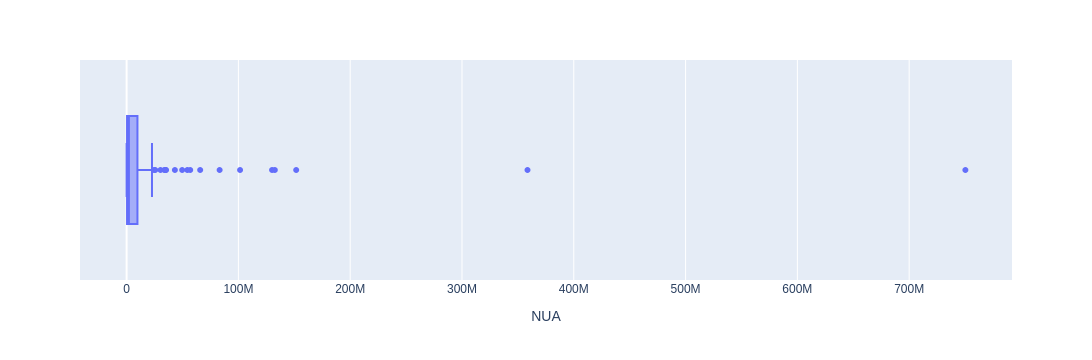

In [84]:
px.box(df_afford, x="NUA", hover_name="Zone")

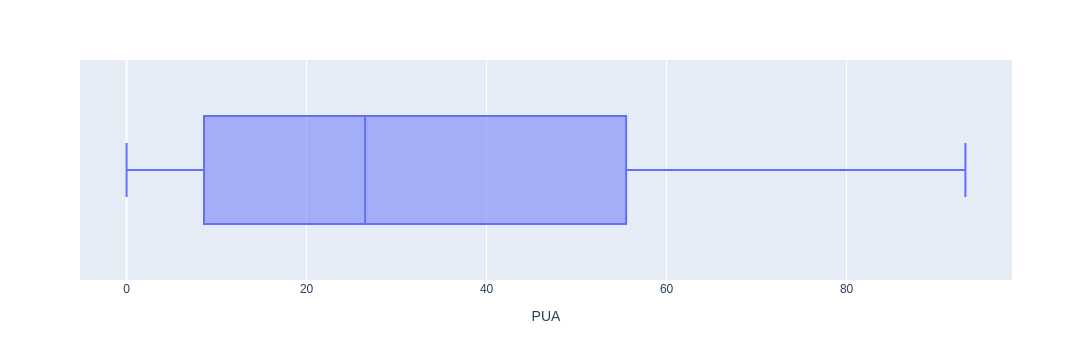

In [85]:
px.box(df_afford, x="PUA", hover_name="Zone")

# Données de la Banque Mondiale

## Stabilité politique (2018)

Source : https://data360.worldbank.org/en/indicator/GOV_WGI_PV

GS = Governance Score

In [86]:
df_gs = pd.read_csv(data_path + "wb-gs.csv")
df_gs

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ESP,GOV_WGI_PV,_Z,_Z,_Z,U,...,66.491535,66.331766,63.848716,64.771717,63.616868,64.106167,65.601442,61.736665,61.516705,59.052278
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SVK,GOV_WGI_PV,_Z,_Z,_Z,U,...,75.184758,71.618405,73.647732,71.234184,70.577237,69.590272,69.190823,68.229438,69.118542,69.951167
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,HND,GOV_WGI_PV,_Z,_Z,_Z,U,...,-0.660492,-0.704792,-0.906570,-0.864354,-0.827138,-0.666353,-0.806377,-0.478162,-0.350767,-0.567158
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BGD,GOV_WGI_PV,_Z,_Z,_Z,U,...,50.016638,49.846091,50.062491,55.251519,55.736924,55.422113,54.292316,53.576761,54.653656,47.259742
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BGR,GOV_WGI_PV,_Z,_Z,_Z,U,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,11.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NIC,GOV_WGI_PV,_Z,_Z,_Z,U,...,56.015395,56.164685,55.925354,40.031463,42.886919,50.087359,52.064330,56.148121,57.784632,57.713062
1292,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,GOV_WGI_PV,_Z,_Z,_Z,U,...,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,10.000000,11.000000
1293,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,JAM,GOV_WGI_PV,_Z,_Z,_Z,U,...,0.245190,0.245190,0.245190,0.245190,0.245190,0.245190,0.245190,0.245190,0.249714,0.247876
1294,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,FIN,GOV_WGI_PV,_Z,_Z,_Z,U,...,85.278293,84.017833,85.347179,83.684965,82.939010,85.662258,85.175132,84.500163,78.959727,80.116013


In [87]:
df_gs.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 63 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   STRUCTURE               1296 non-null   str    
 1   STRUCTURE_ID            1296 non-null   str    
 2   ACTION                  1296 non-null   str    
 3   FREQ                    1296 non-null   str    
 4   REF_AREA                1296 non-null   str    
 5   INDICATOR               1296 non-null   str    
 6   SEX                     1296 non-null   str    
 7   AGE                     1296 non-null   str    
 8   URBANISATION            1296 non-null   str    
 9   UNIT_MEASURE            1296 non-null   str    
 10  COMP_BREAKDOWN_1        1296 non-null   str    
 11  COMP_BREAKDOWN_2        1296 non-null   str    
 12  COMP_BREAKDOWN_3        1296 non-null   str    
 13  UNIT_TYPE               1296 non-null   str    
 14  DECIMALS                1296 non-null   int64  
 15

In [88]:
pd.set_option("display.max_rows", None)
print(df_gs.nunique())
pd.reset_option("display.max_rows")

STRUCTURE                   1
STRUCTURE_ID                1
ACTION                      1
FREQ                        1
REF_AREA                  216
INDICATOR                   1
SEX                         1
AGE                         1
URBANISATION                1
UNIT_MEASURE                1
COMP_BREAKDOWN_1            6
COMP_BREAKDOWN_2            1
COMP_BREAKDOWN_3            1
UNIT_TYPE                   1
DECIMALS                    1
DATABASE_ID                 1
TIME_FORMAT                 1
UNIT_MULT                   1
OBS_STATUS                  1
OBS_CONF                    1
FREQ_LABEL                  1
REF_AREA_LABEL            216
INDICATOR_LABEL             1
SEX_LABEL                   1
AGE_LABEL                   1
URBANISATION_LABEL          1
UNIT_MEASURE_LABEL          1
COMP_BREAKDOWN_1_LABEL      6
COMP_BREAKDOWN_2_LABEL      1
COMP_BREAKDOWN_3_LABEL      1
UNIT_TYPE_LABEL             1
DECIMALS_LABEL              1
DATABASE_ID_LABEL           1
TIME_FORMA

In [89]:
df_gs.groupby(["COMP_BREAKDOWN_1","COMP_BREAKDOWN_1_LABEL"]).size()

COMP_BREAKDOWN_1  COMP_BREAKDOWN_1_LABEL                                                     
WGI_EST           Metric: Governance estimate (approx. -2.5 to +2.5)                             216
WGI_SC            Metric: Governance score (0-100)                                               216
WGI_SC_LB         Metric: Lower bound of the 90% confidence interval for the governance score    216
WGI_SC_UB         Metric: Upper bound of the 90% confidence interval for the governance score    216
WGI_SE            Metric: Standard error of the governance estimate                              216
WGI_SR            Metric: Number of sources                                                      216
dtype: int64

In [90]:
df_gs = df_gs[ (df_gs["COMP_BREAKDOWN_1"] == "WGI_SC") ]
df_gs = df_gs[["REF_AREA","REF_AREA_LABEL","2018"]]
df_gs = df_gs.dropna()
df_gs.rename(columns={"REF_AREA":"ISO3","REF_AREA_LABEL":"Zone","2018":"GS"}, inplace=True)
df_gs.sort_values("ISO3", inplace=True)
df_gs.set_index("ISO3", inplace=True)
df_gs.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 214 entries, ABW to ZWE
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    214 non-null    str    
 1   GS      214 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.7 KB


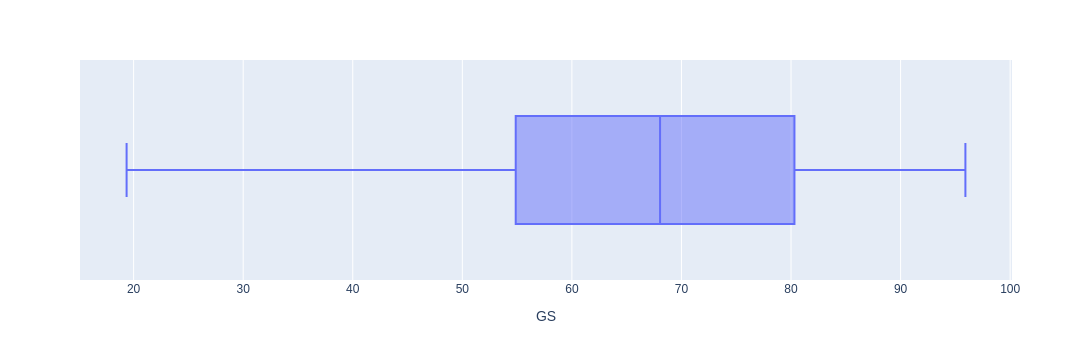

In [91]:
px.box(df_gs, x="GS", hover_name=df_gs.index)

## Indice de performance logistique (2018)

Source : https://data.worldbank.org/indicator/LP.LPI.OVRL.XQ

LPI = Logistics Performance Indicator

In [92]:
df_lpi = pd.read_csv(data_path + "wb-lpi.csv", skiprows=4)
df_lpi

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.492222,NaN,NaN,NaN,2.618182,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.950000,NaN,NaN,NaN,1.900000,NaN,NaN,NaN,NaN
3,NaN,AFW,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.413333,NaN,NaN,NaN,2.473333,NaN,NaN,NaN,NaN
4,Angola,AGO,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.050000,NaN,NaN,NaN,2.100000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yémen, Rép. du",YEM,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.270000,NaN,NaN,NaN,2.200000,NaN,NaN,NaN,NaN
263,Afrique du Sud,ZAF,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.380000,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN
264,Zambie,ZMB,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.530000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
df_lpi.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

In [94]:
df_lpi.nunique()

Country Name      264
Country Code      266
Indicator Name      1
Indicator Code      1
1960                0
                 ... 
2022               64
2023                0
2024                0
2025                0
Unnamed: 70         0
Length: 71, dtype: int64

In [95]:
df_lpi.groupby(["Indicator Name","Indicator Code"]).size()

Indicator Name                                                                 Indicator Code
Indice de performance logistique : performance globale (1=faible et 5=élevée)  LP.LPI.OVRL.XQ    266
dtype: int64

In [96]:
df_lpi = df_lpi[["Country Code","Country Name","2018"]]
df_lpi = df_lpi.dropna()
df_lpi.rename(columns={"Country Code":"ISO3","Country Name":"Zone","2018":"LPI"}, inplace=True)
df_lpi.sort_values("ISO3", inplace=True)
df_lpi.set_index("ISO3", inplace=True)
df_lpi.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 205 entries, AFG to ZWE
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    205 non-null    str    
 1   LPI     205 non-null    float64
dtypes: float64(1), str(1)
memory usage: 8.3 KB


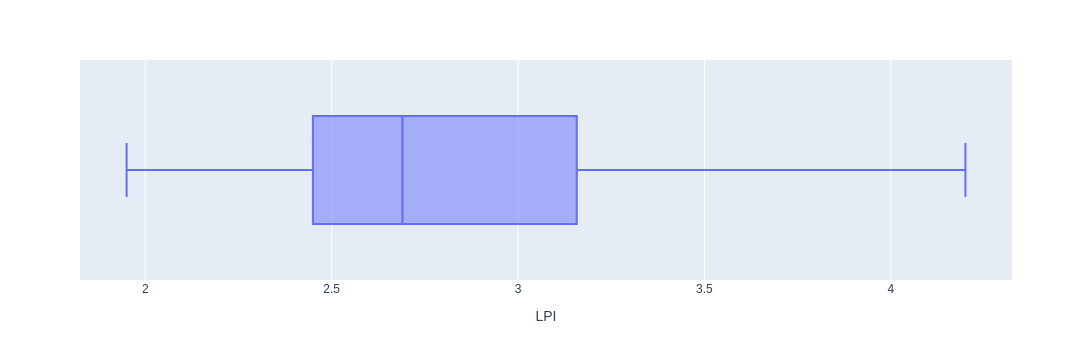

In [97]:
px.box(df_lpi, x="LPI", hover_name=df_lpi.index)

## Facilité à faire des affaires (2018)

Source : https://databank.worldbank.org/source/doing-business/Series/IC.BUS.EASE.DFRN.XQ.DB1719

EDB = Ease of Doing Business

In [98]:
df_edb = pd.read_csv(data_path + "wb-edb.csv", encoding="latin1", skipfooter=5, engine="python")
df_edb

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019]
0,Afghanistan,AFG,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,39.25519,38.93563,37.13062,44.20343,44.06497
1,Albania,ALB,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,58.07559,64.16093,66.8377,66.99561,67.74847
2,Algeria,DZA,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,44.2486,46.10981,46.22686,48.49803,48.59758
3,Angola,AGO,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,37.57368,37.65132,39.00774,41.20205,41.28838
4,Antigua and Barbuda,ATG,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,59.23927,58.80632,59.79669,59.85514,60.28342
...,...,...,...,...,...,...,...,...,...
186,Vietnam,VNM,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,62.60371,65.28861,66.9796,68.56869,69.76594
187,West Bank and Gaza,PSE,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,54.17414,55.48372,59.27638,59.66608,59.97873
188,"Yemen, Rep.",YEM,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,38.4318,31.20833,31.26677,30.67289,31.76299
189,Zambia,ZMB,Global: Ease of doing business score (DB17-20 ...,IC.BUS.EASE.DFRN.XQ.DB1719,60.45046,60.25434,64.23311,65.71170,66.93648


In [99]:
df_edb.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   191 non-null    str    
 1   Country Code   191 non-null    str    
 2   Series Name    191 non-null    str    
 3   Series Code    191 non-null    str    
 4   2015 [YR2015]  191 non-null    str    
 5   2016 [YR2016]  191 non-null    str    
 6   2017 [YR2017]  191 non-null    str    
 7   2018 [YR2018]  191 non-null    float64
 8   2019 [YR2019]  191 non-null    float64
dtypes: float64(2), str(7)
memory usage: 35.9 KB


In [100]:
df_edb.nunique()

Country Name     191
Country Code     191
Series Name        1
Series Code        1
2015 [YR2015]    191
2016 [YR2016]    191
2017 [YR2017]    191
2018 [YR2018]    191
2019 [YR2019]    191
dtype: int64

In [101]:
df_edb.groupby(["Series Name","Series Code"]).size()

Series Name                                                 Series Code               
Global: Ease of doing business score (DB17-20 methodology)  IC.BUS.EASE.DFRN.XQ.DB1719    191
dtype: int64

In [102]:
df_edb = df_edb[["Country Code","Country Name","2018 [YR2018]"]]
df_edb.rename(columns={"Country Code":"ISO3","Country Name":"Zone","2018 [YR2018]":"EDB"}, inplace=True)
df_edb.sort_values("ISO3", inplace=True)
df_edb.set_index("ISO3", inplace=True)
df_edb.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 191 entries, AFG to ZWE
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    191 non-null    str    
 1   EDB     191 non-null    float64
dtypes: float64(1), str(1)
memory usage: 6.8 KB


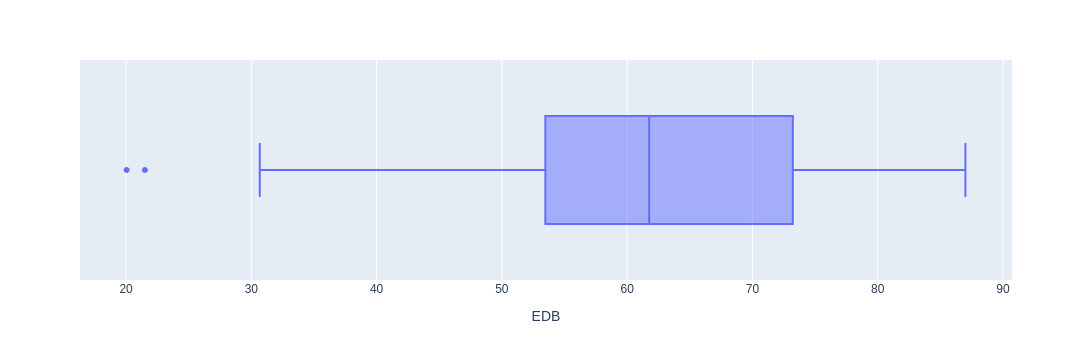

In [103]:
px.box(df_edb, x="EDB", hover_name=df_edb.index)

# Données du CEPII

Centre d'études prospectives et d'informations internationales :
[site web](https://www.cepii.fr/),
[Wikipédia](https://fr.wikipedia.org/wiki/Centre_d%27%C3%A9tudes_prospectives_et_d%27informations_internationales)

## Distances inter-pays

Source : https://www.cepii.fr/CEPII/fr/bdd_modele/bdd_modele_item.asp?id=6

In [104]:
df_dist = pd.read_excel(data_path + "cepii-dist.xls")
df_dist

,iso_o,iso_d,contig,comlang_off,comlang_ethno,colony,comcol,curcol,col45,smctry,dist,distcap,distw,distwces
0,ABW,ABW,0,0,0,0,0,0,0,0,5.225315,5.225315,25.09354,23.04723
1,ABW,AFG,0,0,0,0,0,0,0,0,13257.810000,13257.810000,13168.22,13166.37
2,ABW,AGO,0,0,0,0,0,0,0,0,9516.913000,9516.913000,9587.316,9584.193
3,ABW,AIA,0,0,1,0,0,0,0,0,983.268200,983.268200,976.8974,976.8916
4,ABW,ALB,0,0,0,0,0,0,0,0,9091.742000,9091.742000,9091.576,9091.466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50171,ZWE,YUG,0,0,0,0,0,0,0,0,7056.402000,7056.402000,7046.432,7042.83
50172,ZWE,ZAF,1,1,1,0,0,0,0,0,2186.206000,926.174300,1258.552,1101.438
50173,ZWE,ZAR,0,0,0,0,0,0,0,0,2283.061000,2283.061000,1930.976,1719.147
50174,ZWE,ZMB,1,1,1,0,1,0,0,0,396.804100,396.804100,583.7954,525.0734


In [105]:
df_dist.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 50176 entries, 0 to 50175
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso_o          50176 non-null  str    
 1   iso_d          50176 non-null  str    
 2   contig         50176 non-null  int64  
 3   comlang_off    50176 non-null  int64  
 4   comlang_ethno  50176 non-null  int64  
 5   colony         50176 non-null  int64  
 6   comcol         50176 non-null  int64  
 7   curcol         50176 non-null  int64  
 8   col45          50176 non-null  int64  
 9   smctry         50176 non-null  int64  
 10  dist           50176 non-null  float64
 11  distcap        50176 non-null  float64
 12  distw          50176 non-null  object 
 13  distwces       50176 non-null  object 
dtypes: float64(2), int64(8), object(2), str(2)
memory usage: 5.6+ MB


In [106]:
df_dist.nunique()

iso_o              224
iso_d              224
contig               2
comlang_off          2
comlang_ethno        2
colony               2
comcol               2
curcol               2
col45                2
smctry               2
dist             25135
distcap          25135
distw            25526
distwces         25606
dtype: int64

In [107]:
iso_o = np.sort(df_dist["iso_o"].unique())
iso_d = np.sort(df_dist["iso_d"].unique())
print("Codes ISO3 identiques dans les colonnes Origine/Destination ?", ("OUI" if (iso_o == iso_d).all() else "NON"))

Codes ISO3 identiques dans les colonnes Origine/Destination ? OUI


In [108]:
from itertools import product
assert (pd.DataFrame(product(iso_o, iso_d), columns=["iso_o","iso_d"]) == df_dist[["iso_o","iso_d"]]).all().all()
print("Toutes les paires de pays (avec symétrie) sont générées par ordre lexicographique croissant.")

Toutes les paires de pays (avec symétrie) sont générées par ordre lexicographique croissant.


In [109]:
df_dist = df_dist[ (df_dist["iso_o"] == "FRA") ]
df_dist = df_dist[["iso_d","dist"]]
df_dist.rename(columns={"iso_d":"ISO3","dist":"Distance"}, inplace=True)
df_dist.set_index("ISO3", inplace=True)
df_dist.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 224 entries, ABW to ZWE
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  224 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB


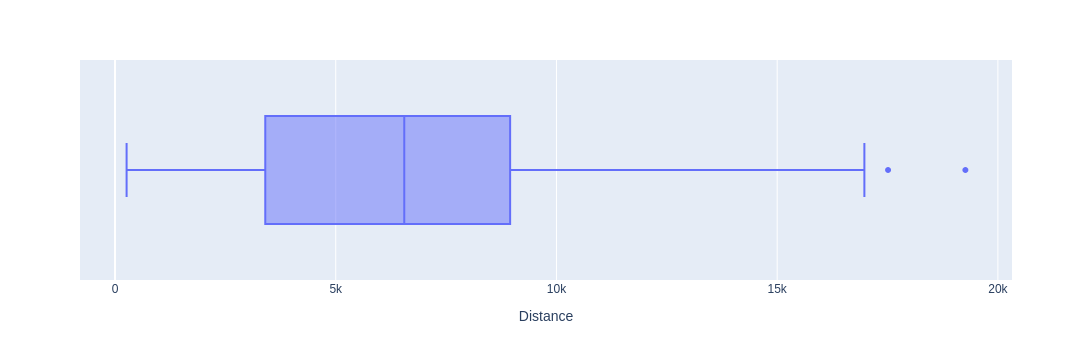

In [110]:
px.box(df_dist, x="Distance", hover_name=df_dist.index)

In [111]:
df_dist.nsmallest(10, "Distance")

,Distance
ISO3,
BEL,262.3845
FRA,278.1876
LUX,289.1023
GBR,342.9475
NLD,427.9169
CHE,436.0778
DEU,439.8984
AND,711.5485
IRL,778.2031


In [112]:
df_dist.nlargest(10, "Distance")

,Distance
ISO3,
NZL,19263.88
NFK,17511.67
AUS,16975.46
TON,16941.44
NCL,16757.74
NIU,16639.50
FJI,16595.08
COK,16568.87
VUT,16346.35


# Jointure

## Nombre de pays sélectionnés et part de la population mondiale représentée

In [113]:
dfs_oc = {
    ("OC", "dispo_alim"): df_dispo_alim_,
    ("OC", "population"): df_population_,
}

In [114]:
dfs = {
    ("FAO", "dispo_alim"): df_dispo_alim,
    ("FAO", "population"): df_population,
    ("FAO", "economy"): df_economy,
    ("FAO", "afford"): df_afford,
    ("WB", "gs"): df_gs,
    ("WB", "lpi"): df_lpi,
    ("WB", "edb"): df_edb,
    ("CEPII", "dist"): df_dist,
}

In [115]:
from functools import reduce
index_inter = reduce(pd.Index.intersection, (df.index for df in dfs.values())).difference(["FRA"])
index_union = reduce(pd.Index.union       , (df.index for df in dfs.values()))
index_diff  = df_population.index.difference(index_inter)

In [116]:
print(f"Nombre de pays sélectionnés = {len(index_inter)}")

Nombre de pays sélectionnés = 101


In [117]:
den = df_population["Population"].sum()
num = df_population.loc[index_inter,"Population"].sum()
print(f"Estimation de la population mondiale = {den:,}")
print(f"Estimation de la population sélectionnée = {num:,} = {num/den:.2%} de la population mondiale")

Estimation de la population mondiale = 7,727,168,971.0
Estimation de la population sélectionnée = 6,479,199,066.0 = 83.85% de la population mondiale


In [118]:
df_missing = df_population.loc[index_diff][["Zone","Population"]]
for key, val in dfs_oc.items():
    df_missing[key] = df_missing["Zone"].isin(val["Zone"]) # Hypothèse : même nom français de pays dans tous les fichiers FAO
for key, val in dfs.items():
    df_missing[key] = df_missing.index.isin(val.index)
print(f"Nombre de pays exclus = {df_missing.shape[0]}")
df_missing.nlargest(20, "Population")

Nombre de pays exclus = 132


,Zone,Population,"(OC, dispo_alim)","(OC, population)","(FAO, dispo_alim)","(FAO, population)","(FAO, economy)","(FAO, afford)","(WB, gs)","(WB, lpi)","(WB, edb)","(CEPII, dist)"
ISO3,,,,,,,,,,,,
JPN,Japon,126913432.0,True,True,False,True,True,True,True,True,True,True
ETH,Éthiopie,112664152.0,False,True,False,True,True,True,True,False,True,True
COD,République démocratique du Congo,90047644.0,False,True,True,True,True,True,True,True,True,False
FRA,France,65519543.0,True,True,True,True,True,True,True,True,True,True
TZA,République-Unie de Tanzanie,57437144.0,False,True,True,True,True,True,True,False,True,True
UKR,Ukraine,45208907.0,True,True,True,True,True,False,True,True,True,True
ARG,Argentine,44654882.0,True,True,True,True,True,False,True,True,True,True
SDN,Soudan,44230596.0,False,True,False,True,True,True,True,True,True,True
AFG,Afghanistan,36743039.0,False,True,True,True,True,False,True,True,True,True


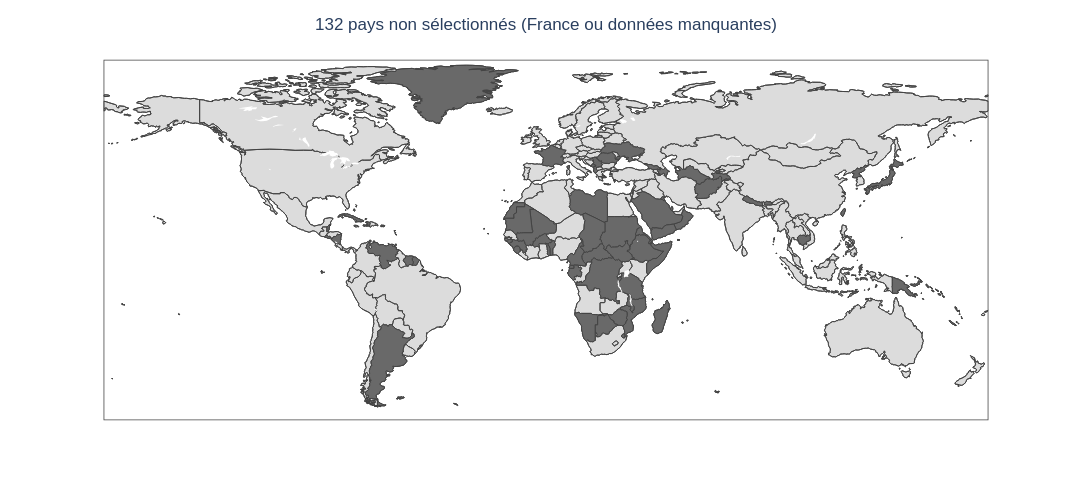

In [119]:
fig = px.choropleth(
    df_missing, locations=df_missing.index, hover_name="Zone",
    color_discrete_sequence=["DimGray"], width=1000, height=500,
)
fig.update_geos(showcountries=True, landcolor="Gainsboro", lataxis_range=(-55,80)) # Hide poles
fig.update_layout(title=f"{df_missing.shape[0]} pays non sélectionnés (France ou données manquantes)", title_x=0.5, showlegend=False)
fig.show()

## Regroupement des DataFrames

In [120]:
df_zone = df_population[["Zone"]]
for df in dfs.values():
    if "Zone" in df.columns:
        del df["Zone"]
dfs[("FAO","Zone")] = df_zone
df_zone

,Zone
ISO3,
ABW,Aruba
AFG,Afghanistan
AGO,Angola
AIA,Anguilla
ALB,Albanie
...,...
WSM,Samoa
YEM,Yémen
ZAF,Afrique du Sud


In [121]:
df_final = pd.concat((df.loc[index_inter] for df in dfs.values()), axis=1)
df_final

,Production,Importation,Exportation,TDI,TAS,Population,Croissance Population,Croissance PIB,Croissance PIB par habitant,PIB,PIB par habitant,NUA,PUA,GS,LPI,EDB,Distance,Zone
ISO3,,,,,,,,,,,,,,,,,,
AGO,41.0,335.0,0.0,0.890957,0.109043,31297155.0,45.037561,-17.007853,-19.824847,1.013532e+05,3238.416118,19800000.0,63.2,58.962480,2.05,41.20205,6510.322,Angola
ARE,47.0,612.0,61.0,1.023411,0.078595,9346870.0,48.300306,9.354948,8.038236,4.270494e+05,45689.032634,200000.0,2.5,80.134659,3.96,81.58883,5249.535,Émirats arabes unis
ARM,12.0,33.0,0.0,0.733333,0.266667,2909965.0,-1.690039,8.071874,8.257530,1.245794e+04,4281.131507,1400000.0,49.7,65.827944,2.61,73.19187,3434.071,Arménie
AUS,1235.0,16.0,39.0,0.013201,1.018977,25119706.0,17.543349,3.056880,1.462323,1.454947e+06,57920.551509,800000.0,3.2,80.996137,3.75,80.70552,16975.460,Australie
AUT,152.0,114.0,83.0,0.622951,0.830601,8841650.0,6.228298,9.075388,8.546483,4.525823e+05,51187.535062,200000.0,2.3,80.312654,4.03,78.73995,1035.144,Autriche
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,22298.0,128.0,3776.0,0.006863,1.195603,335056497.0,9.865276,5.325355,4.428877,2.065652e+07,61650.844422,15900000.0,4.7,70.856532,3.89,83.57395,5838.157,États-Unis d'Amérique
UZB,59.0,7.0,0.0,0.106061,0.893939,32373490.0,17.744157,-14.837336,-16.295528,5.287011e+04,1633.129681,6000000.0,18.4,62.273970,2.58,67.75199,5153.064,Ouzbékistan
VNM,930.0,162.0,22.0,0.151402,0.869159,96237319.0,12.986708,10.219479,9.005081,3.101065e+05,3222.310015,10500000.0,10.9,64.967558,3.27,68.56869,9208.554,Viet Nam


In [122]:
df_final.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 101 entries, AGO to ZMB
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Production                   101 non-null    float64
 1   Importation                  101 non-null    float64
 2   Exportation                  101 non-null    float64
 3   TDI                          101 non-null    float64
 4   TAS                          101 non-null    float64
 5   Population                   101 non-null    float64
 6   Croissance Population        101 non-null    float64
 7   Croissance PIB               101 non-null    float64
 8   Croissance PIB par habitant  101 non-null    float64
 9   PIB                          101 non-null    float64
 10  PIB par habitant             101 non-null    float64
 11  NUA                          101 non-null    float64
 12  PUA                          101 non-null    float64
 13  GS                           101 n

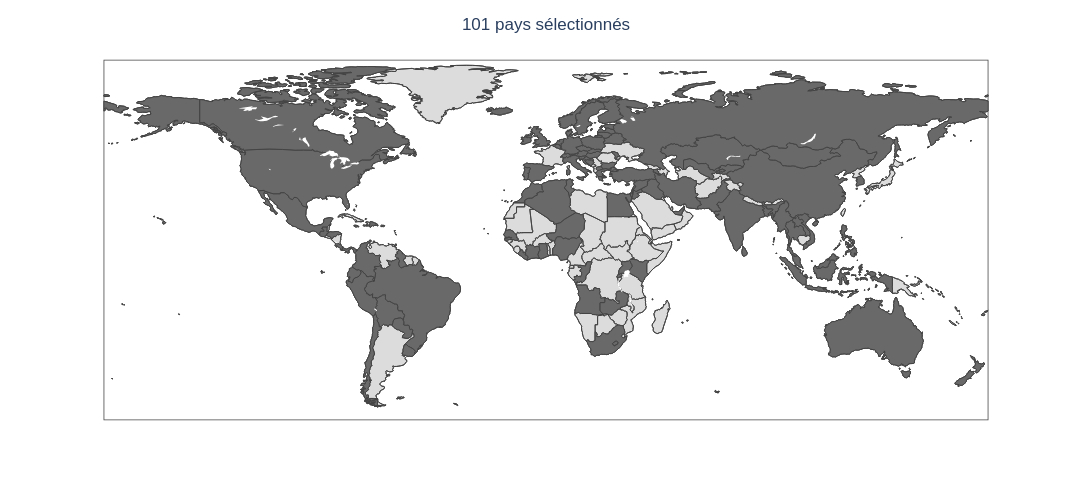

In [123]:
fig = px.choropleth(
    df_final, locations=df_final.index, hover_name="Zone",
    color_discrete_sequence=["DimGray"], width=1000, height=500,
)
fig.update_geos(showcountries=True, landcolor="Gainsboro", lataxis_range=(-55,80)) # Hide poles
fig.update_layout(title=f"{df_final.shape[0]} pays sélectionnés", title_x=0.5, showlegend=False)
fig.show()

## Feature engineering : nombre de personnes ayant les moyens d'acheter une alimentation saine

In [124]:
df_final["Pop - NUA"] = df_final["Population"] - df_final["NUA"]
df_final["Pop - NUA"].describe()

count    1.010000e+02
mean     4.159207e+07
std      1.260314e+08
min      3.528540e+05
25%      3.187000e+06
50%      9.162306e+06
75%      3.171097e+07
max      1.060409e+09
Name: Pop - NUA, dtype: float64

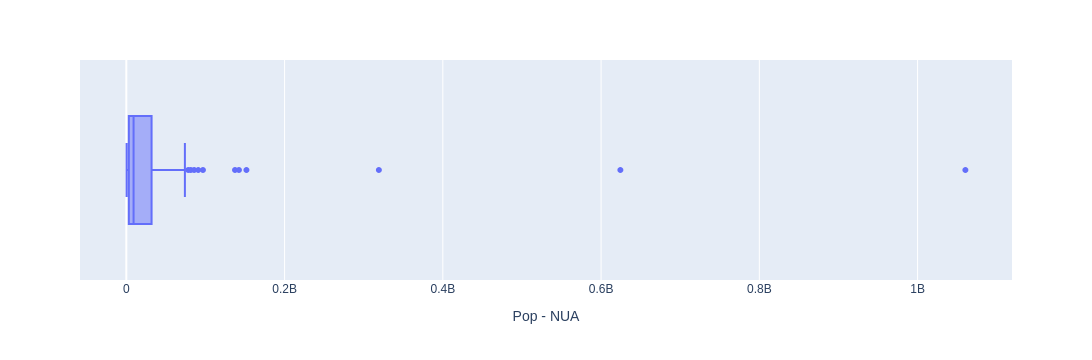

In [125]:
px.box(df_final, x="Pop - NUA", hover_name="Zone")

# Export des données préparées

In [126]:
# Réorganisation des colonnes
df_final.insert(0, "Zone", df_final.pop("Zone"))
df_final.insert(13, "Pop - NUA", df_final.pop("Pop - NUA"))
df_final.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 101 entries, AGO to ZMB
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Zone                         101 non-null    str    
 1   Production                   101 non-null    float64
 2   Importation                  101 non-null    float64
 3   Exportation                  101 non-null    float64
 4   TDI                          101 non-null    float64
 5   TAS                          101 non-null    float64
 6   Population                   101 non-null    float64
 7   Croissance Population        101 non-null    float64
 8   Croissance PIB               101 non-null    float64
 9   Croissance PIB par habitant  101 non-null    float64
 10  PIB                          101 non-null    float64
 11  PIB par habitant             101 non-null    float64
 12  NUA                          101 non-null    float64
 13  Pop - NUA                    101 n

In [127]:
df_final.to_csv(data_path + "ready.csv")